# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; text-align: center; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">🖼️ 2-Steganography LSB</span>

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Imports</span>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Show Image</span>

In [2]:
def show_image(img, title):
    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Embedding of Msg in LSB</span>

In [3]:
def embed_lsb(org_img, secret_msg, stego_path):
    delimiter = "##"
    secret_msg += delimiter
    secret_msg_binary = ''.join([format(ord(i), '08b') for i in secret_msg])
    # get length of secret msg
    len_secret_msg_binary = len(secret_msg_binary)
    # flatten img from 2D to 1D
    flat_org_img = org_img.flatten()
    #embed secret msg in LSB
    for i in range(len_secret_msg_binary):
        flat_org_img[i] = (flat_org_img[i] & ~1) | int(secret_msg_binary[i])
    # reshape image back to 2D from 1D
    stego_img = flat_org_img.reshape(org_img.shape)
    #write to file
    cv2.imwrite(stego_path,stego_img)

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Extract Msg from LSB</span>

In [4]:
def extract_lsb(stego_img):
    #flat image
    flat_stego_img = stego_img.flatten()
    #extract LSB
    extracted_bin = ""
    for pixel in flat_stego_img:
        extracted_bin += str(pixel & 1)
    #bit to bytes
    msg = ""
    for i in range(0, len(extracted_bin), 8):
        byte = extracted_bin[i:i+8]
        char = chr(int(byte,2))
        msg += char
        if msg.endswith("##"):
            break

    msg = msg.rstrip("##")
    return msg

# <span style="display:block; color:#0066cc; font-family: 'Consolas', monospace; border-top:6px solid #ff6b6b; padding:15px; background-color:#f0f8ff; border-radius:8px; font-weight: bold; letter-spacing:1px">Execution</span>

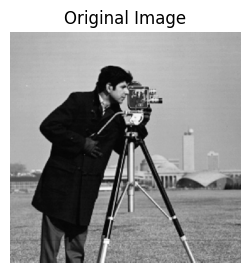

Secret Message to Embed: A quick brown fox jumps over a lazy dog


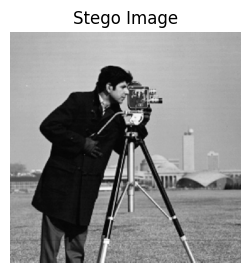

Extracted Secret Message: A quick brown fox jumps over a lazy dog


In [5]:
if __name__ == "__main__":
    img_path = "/kaggle/input/image-processing/Grayscale/cameraman.png"
    stego_path = "/kaggle/working/stego_img.png"
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    show_image(img, "Original Image")

    secret_msg = "A quick brown fox jumps over a lazy dog"
    
    #Embed MSG
    print("Secret Message to Embed: "+secret_msg)
    embed_lsb(img, secret_msg, stego_path)
    show_image(img, "Stego Image")
    
    #Extract MSG
    stego_img = cv2.imread(stego_path, cv2.IMREAD_GRAYSCALE)
    extracted_secret_msg_binary = extract_lsb(stego_img)
    print("Extracted Secret Message: "+extracted_secret_msg_binary)